In [1]:
# Setup
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from recsys.config import load_config, set_seed
from recsys import plots
cfg = load_config()
set_seed(cfg["seed"])
plots.set_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from recsys.data import load_raw, load_dataset
from recsys import eda, experiments as X
from recsys.candidates import article_embeddings, Interactions, als
from recsys.features import feature_columns
from recsys.pipeline import load_train, load_week, categories, build_tables
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
raw = load_raw(cfg["paths"]["processed"])
ds = load_dataset(cfg)
tx = ds.transactions

In [2]:
# 1. Cleaning: customers before vs after
cols = ["FN", "Active", "club_member_status", "fashion_news_frequency", "age"]
pd.DataFrame({"raw_missing": raw["customers"][cols].isna().sum(), "clean_missing": ds.customers[cols].isna().sum(), "rule": ["missing = 0 (not subscribed)", "missing = 0", "missing = UNKNOWN", "None and missing merged into NONE", "kept missing, median in age_filled, flag in age_missing, band = Unknown"]})

,raw_missing,clean_missing,rule
FN,181680,0,missing = 0 (not subscribed)
Active,184290,0,missing = 0
club_member_status,1218,0,missing = UNKNOWN
fashion_news_frequency,3275,0,None and missing merged into NONE
age,3241,3241,"kept missing, median in age_filled, flag in ag..."


In [3]:
# 2. Cleaning: transactions (duplicates = units, outliers kept)
pd.Series({"raw_rows": len(raw["transactions"]), "clean_rows": len(tx), "rows_dropped": len(raw["transactions"]) - len(tx), "duplicate_rows_kept_as_units": int(raw["transactions"].duplicated().sum()), "online_share": tx["online"].mean()})

raw_rows                       789,049.0000
clean_rows                     789,049.0000
rows_dropped                         0.0000
duplicate_rows_kept_as_units    66,416.0000
online_share                         0.6517
dtype: float64

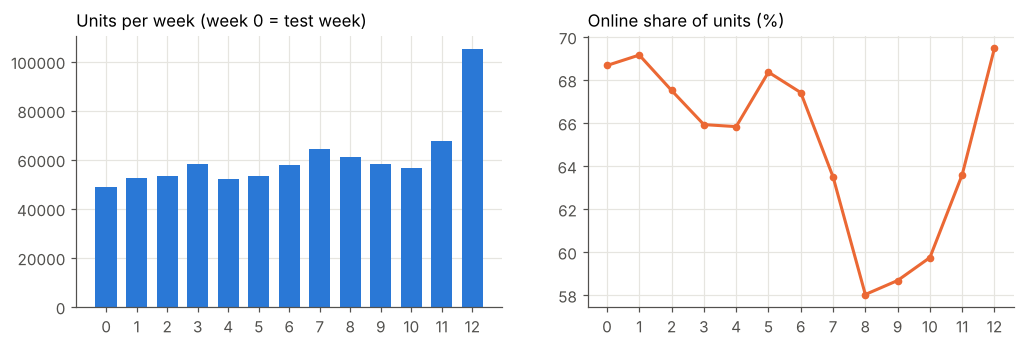

In [4]:
# 3. Weekly units and online share
wk = tx.groupby("week").agg(units=("article_id", "size"), online=("online", "mean")).sort_index(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].bar(wk.index.astype(str), wk["units"], color=plots.BLUE, width=0.7)
axes[0].invert_xaxis()
axes[0].set_title("Units per week (week 0 = test week)")
axes[1].plot(wk.index.astype(str), wk["online"] * 100, color=plots.ORANGE, lw=2, marker="o", ms=4)
axes[1].invert_xaxis()
axes[1].set_title("Online share of units (%)")
plots.save(fig, "02_weekly_volume")

In [5]:
# 4. How predictable is next week's basket from the last 8 weeks?
pred = eda.predictability(tx, ds.articles, [0, 1, 2, 3, 4], cfg["weeks"]["history_weeks"], cfg["candidates"]["popular_n"])
pred.to_csv(cfg["paths"]["tables"] / "predictability.csv", index=False)
pred

,week,pairs,bought_before,same_product_bought_before,in_last_week_top,buyers_with_history
0,0,43597,0.0265,0.0448,0.0547,0.6169
1,1,46881,0.0260,0.0444,0.0442,0.6177
2,2,47994,0.0246,0.0419,0.0485,0.6068
3,3,52521,0.0200,0.0372,0.0492,0.6125
4,4,46688,0.0239,0.0456,0.0400,0.6512


index_group_name,Baby/Children,Divided,Ladieswear,Menswear,Sport
age_band,,,,,
16-24,0.0102,0.2710,0.6124,0.0579,0.0485
25-34,0.0193,0.1995,0.6747,0.0512,0.0553
35-44,0.0378,0.1998,0.6605,0.0565,0.0454
45-54,0.0193,0.2023,0.6582,0.0752,0.0451
55+,0.0135,0.1669,0.7167,0.0669,0.0360
Unknown,0.0244,0.1810,0.6901,0.0629,0.0416


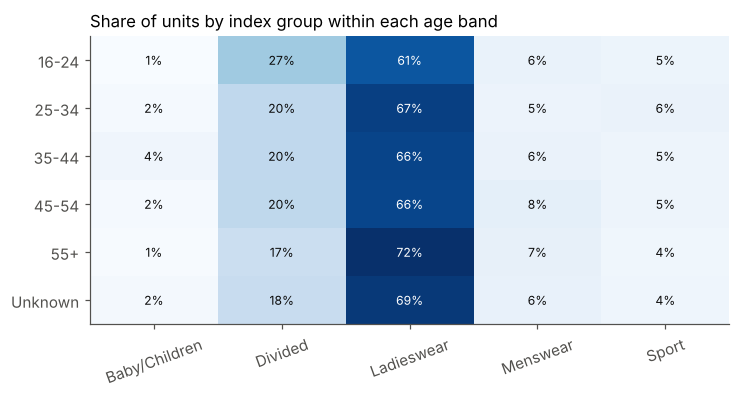

In [6]:
# 5. Age vs product mix (share of each age band's units)
mix = eda.age_mix(tx, ds.customers, ds.articles)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
im = ax.imshow(mix.to_numpy() * 100, cmap="Blues", aspect="auto")
ax.set_xticks(range(mix.shape[1]), mix.columns, rotation=20)
ax.set_yticks(range(mix.shape[0]), mix.index)
ax.grid(False)
[ax.text(j, i, f"{mix.iat[i, j] * 100:.0f}%", ha="center", va="center", fontsize=8, color="white" if mix.iat[i, j] > 0.35 else plots.INK) for i in range(mix.shape[0]) for j in range(mix.shape[1])]
ax.set_title("Share of units by index group within each age band")
plots.save(fig, "02_age_mix")
mix

In [7]:
# 5b. Repeat behaviour by age band (target weeks 0 to 2)
by_band = eda.predictability_by_band(tx, ds.customers, ds.articles, [0, 1, 2], cfg["weeks"]["history_weeks"])
by_band.to_csv(cfg["paths"]["tables"] / "predictability_by_age_band.csv", index=False)
by_band

,age_band,bought_before,other_colour_before,has_history
0,16-24,0.0199,0.0355,0.5881
1,25-34,0.0261,0.0429,0.6237
2,35-44,0.0317,0.0520,0.6182
3,45-54,0.0277,0.0472,0.6152
4,55+,0.0279,0.0502,0.6032
5,Unknown,0.0152,0.0380,0.4715


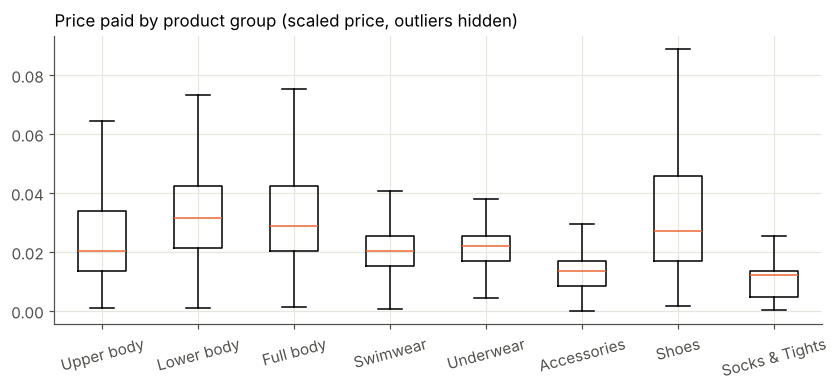

In [8]:
# 6. Price by product group (top 8 groups by units)
top_groups = tx.merge(ds.articles[["article_id", "product_group_name"]], on="article_id")
order = top_groups["product_group_name"].value_counts().head(8).index
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.boxplot([top_groups.loc[top_groups["product_group_name"] == g, "price"] for g in order], showfliers=False, widths=0.5, medianprops={"color": plots.ORANGE})
ax.set_xticks(range(1, len(order) + 1), [g.replace("Garment ", "") for g in order], rotation=15)
ax.set_title("Price paid by product group (scaled price, outliers hidden)")
plots.save(fig, "02_price_by_group")

In [9]:
# 7. Build candidate + feature tables (cached to data/processed/tables)
build_tables(cfg)
train = load_train(cfg)
valid, vx = load_week(cfg, cfg["weeks"]["valid"])
cats = categories(ds)
cols = feature_columns(train)
ft = eda.feature_table()
ft.to_csv(cfg["paths"]["tables"] / "feature_list.csv", index=False)
ft.groupby("group").size()

group
Candidate score       11
Customer              13
Customer x item       10
Item                  11
Item (categorical)     5
dtype: int64

In [10]:
# 8. Engineered features
ft

,feature,group,description
0,rep_count,Customer x item,Times the customer bought this exact item in t...
1,rep_days_since,Customer x item,Days since the customer last bought this item
2,rep_rank,Customer x item,Recency rank of the item in the customer's his...
3,itemcf_score,Candidate score,Item-to-item cosine score from co-purchases
4,itemcf_rank,Candidate score,Rank inside the item-CF list
5,als_score,Candidate score,ALS matrix factorization score
6,als_rank,Candidate score,Rank inside the ALS list
7,content_score,Candidate score,Cosine similarity of item to the customer's PC...
8,content_rank,Candidate score,Rank inside the content-based list
9,sib_pop,Candidate score,Recent sales of another color of a product the...


In [11]:
# 9. Class imbalance
pd.Series({"train_rows": len(train), "train_positive_rate": train["label"].mean(), "valid_rows": len(valid), "valid_positive_rate": valid["label"].mean(), "negatives_per_positive_train": (1 - train["label"].mean()) / train["label"].mean()})

train_rows                     1,018,522.0000
train_positive_rate                    0.0140
valid_rows                     1,191,921.0000
valid_positive_rate                    0.0038
negatives_per_positive_train          70.6008
dtype: float64

,level_0,level_1,r
1797,c_fn,c_news_regular,0.9965
1243,a_pop_4w,a_buyers_4w,0.9933
1795,c_fn,c_active,0.9860
1842,c_active,c_news_regular,0.9825
1381,c_n_tx,c_n_articles,0.9680
1151,a_pop_1w,a_pop_2w,0.9265
1197,a_pop_2w,a_pop_4w,0.9227
1198,a_pop_2w,a_buyers_4w,0.9210
882,a_pop_8w,a_pop_4w,0.8793
883,a_pop_8w,a_buyers_4w,0.8606


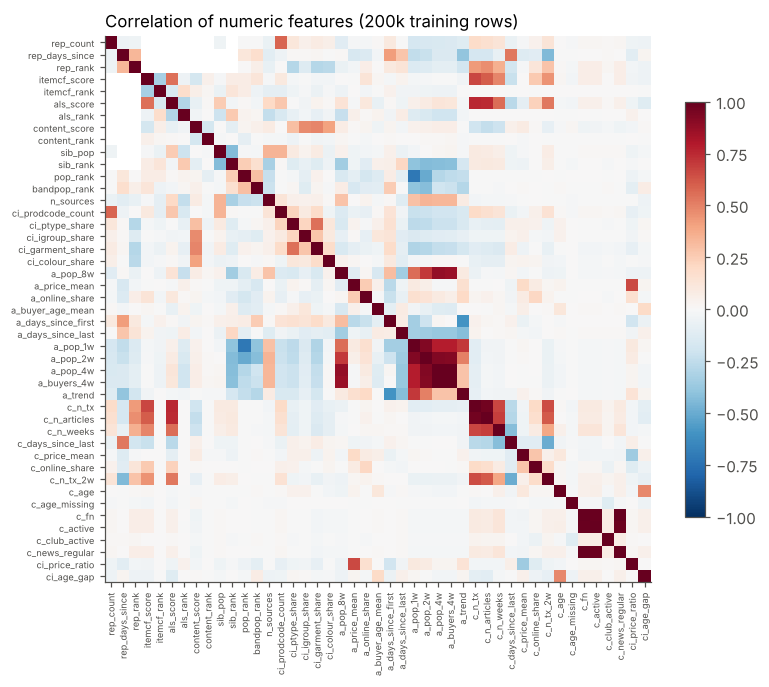

In [12]:
# 10. Correlations between numeric features
xs, ys = X.numeric_sample(train, cols, 200000, cfg["seed"])
corr = xs.corr()
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack().rename("r").reset_index()
high = pairs[pairs["r"].abs() > 0.85].sort_values("r", ascending=False)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=6)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7)
ax.set_title("Correlation of numeric features (200k training rows)")
plots.save(fig, "02_feature_correlation")
high

[]

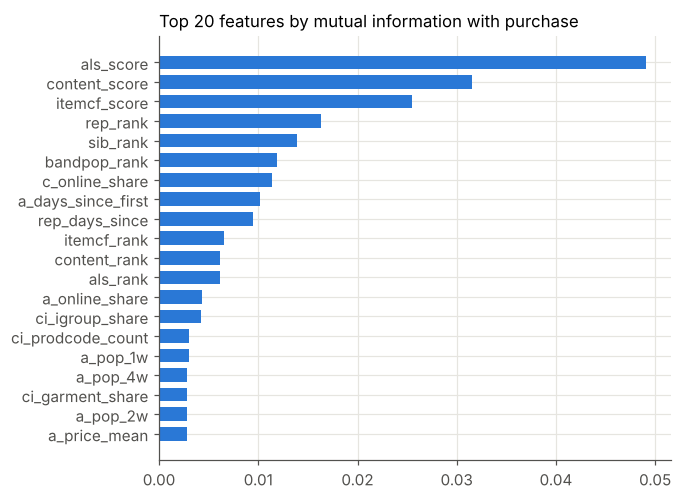

In [13]:
# 11. Feature selection, filter method: variance + mutual information
low_var = X.variance_filter(xs)
mi = X.mutual_information(xs, ys, cfg["seed"])
mi.to_csv(cfg["paths"]["tables"] / "mutual_information.csv", index=False)
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(mi["feature"].head(20)[::-1], mi["mutual_info"].head(20)[::-1], color=plots.BLUE, height=0.7)
ax.set_title("Top 20 features by mutual information with purchase")
plots.save(fig, "02_mutual_information")
low_var

In [14]:
# 12. Feature selection, embedded method: L1 logistic regression
l1 = X.l1_selection(xs, ys, C=0.01, seed=cfg["seed"])
l1.to_csv(cfg["paths"]["tables"] / "l1_coefficients.csv", index=False)
l1_kept = l1.loc[l1["abs_coef"] > 0, "feature"].tolist()
pd.Series({"numeric_features": len(xs.columns), "kept_by_l1": len(l1_kept), "dropped_by_l1": len(xs.columns) - len(l1_kept)})

numeric_features    45
kept_by_l1          22
dropped_by_l1       23
dtype: int64

In [15]:
# 13. Do the selected sets keep accuracy? (same fixed LightGBM settings, validation week)
params = {"num_leaves": 63, "learning_rate": 0.05, "min_child_samples": 100, "colsample_bytree": 0.7, "subsample": 0.8, "reg_lambda": 1.0}
cat_cols = [c for c in cols if c in cats]
sets = {"all features": cols, "top 25 by mutual information + categoricals": mi["feature"].head(25).tolist() + cat_cols, "L1 kept + categoricals": l1_kept + cat_cols}
sel = X.evaluate_sets(train, valid, vx, sets, cats, params, 150, cfg)
sel.to_csv(cfg["paths"]["tables"] / "feature_selection_results.csv", index=False)
sel

,feature_set,n_features,valid_map@12,valid_auc
0,all features,50,0.0301,0.7656
1,top 25 by mutual information + categoricals,30,0.0303,0.7640
2,L1 kept + categoricals,27,0.0291,0.7566


one_hot_columns             600
components_used              24
variance_kept            0.5956
components_for_90pct    over 80
dtype: object

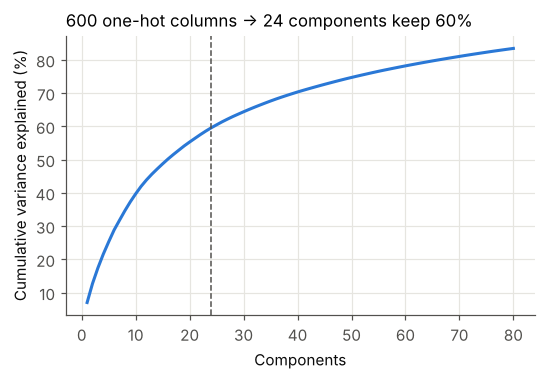

In [16]:
# 14. Dimensionality reduction: PCA on article attributes (one-hot, 105k articles)
from recsys.data import ARTICLE_CATEGORICALS
onehot = pd.get_dummies(ds.articles[ARTICLE_CATEGORICALS], dtype=np.float32)
pca_full = PCA(n_components=80, random_state=cfg["seed"], svd_solver="randomized").fit(onehot.to_numpy() - onehot.to_numpy().mean(axis=0))
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
k = cfg["candidates"]["content_pca_components"]
fig, ax = plt.subplots(figsize=(5.5, 3.3))
ax.plot(range(1, 81), cumvar * 100, color=plots.BLUE, lw=2)
ax.axvline(k, color=plots.GRAY, ls="--", lw=1)
ax.set_xlabel("Components")
ax.set_ylabel("Cumulative variance explained (%)")
ax.set_title(f"{onehot.shape[1]} one-hot columns -> {k} components keep {cumvar[k - 1] * 100:.0f}%")
plots.save(fig, "02_pca_variance")
pd.Series({"one_hot_columns": onehot.shape[1], "components_used": k, "variance_kept": cumvar[k - 1], "components_for_90pct": int(np.searchsorted(cumvar, 0.9) + 1) if cumvar[-1] >= 0.9 else "over 80"})

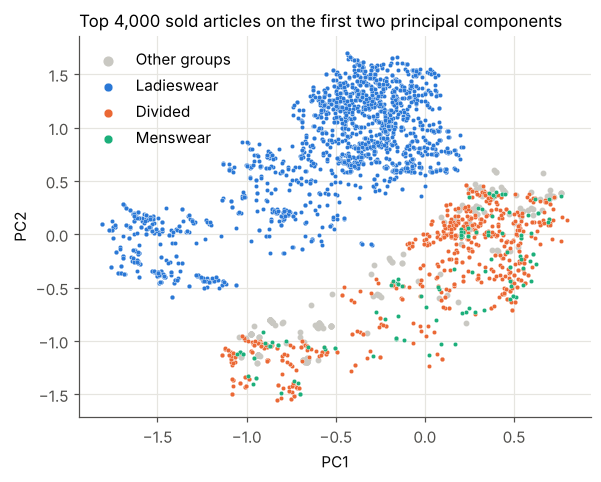

In [17]:
# 15. PCA map of articles sold in the window
emb, _, _ = article_embeddings(ds.articles, k, cfg["seed"])
sold = tx["article_id"].value_counts().head(4000).index
pts = emb.loc[sold, ["pc1", "pc2"]].join(ds.articles.set_index("article_id")["index_group_name"])
groups = ["Ladieswear", "Divided", "Menswear"]
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(pts.loc[~pts["index_group_name"].isin(groups), "pc1"], pts.loc[~pts["index_group_name"].isin(groups), "pc2"], s=8, color="#c9c8c2", label="Other groups")
[ax.scatter(pts.loc[pts["index_group_name"] == g, "pc1"], pts.loc[pts["index_group_name"] == g, "pc2"], s=8, color=c, label=g, edgecolors="white", linewidths=0.2) for g, c in zip(groups, [plots.BLUE, plots.ORANGE, plots.AQUA])]
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(markerscale=2)
ax.set_title("Top 4,000 sold articles on the first two principal components")
plots.save(fig, "02_pca_articles")

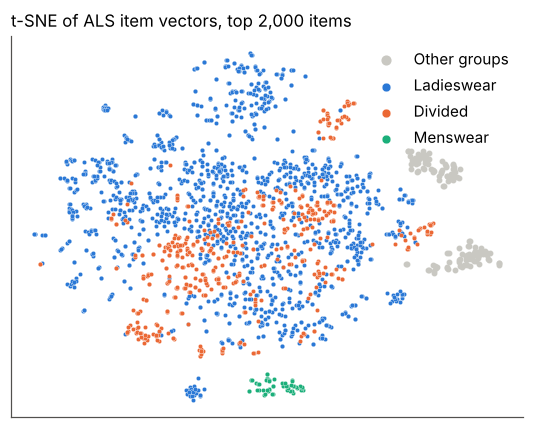

In [18]:
# 16. t-SNE of ALS item embeddings (collaborative signal, not attributes)
from recsys.data import history
hist0 = history(tx, cfg["weeks"]["test"], cfg["weeks"]["history_weeks"])
inter = Interactions(hist0, len(ds.customers))
_, als_model = als(inter, np.array([0]), 1, cfg, cfg["seed"])
top_items = hist0["article_id"].value_counts().head(2000).index.to_numpy()
vecs = als_model.item_factors[inter.item_index.loc[top_items].to_numpy()]
xy = TSNE(n_components=2, random_state=cfg["seed"], init="pca", perplexity=30).fit_transform(np.asarray(vecs))
lab = ds.articles.set_index("article_id").loc[top_items, "index_group_name"].to_numpy()
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(xy[~np.isin(lab, groups), 0], xy[~np.isin(lab, groups), 1], s=8, color="#c9c8c2", label="Other groups")
[ax.scatter(xy[lab == g, 0], xy[lab == g, 1], s=8, color=c, label=g, edgecolors="white", linewidths=0.2) for g, c in zip(groups, [plots.BLUE, plots.ORANGE, plots.AQUA])]
ax.legend(markerscale=2)
ax.set_title("t-SNE of ALS item vectors, top 2,000 items")
ax.set_xticks([])
ax.set_yticks([])
plots.save(fig, "02_tsne_als")